In [ ]:
import marimo as mo
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from itertools import combinations
from tqdm import tqdm
import os
import re
import yaml
from torchgeodemo import autoencoder_train_latent
#notebook to rest reconstruction error of PCA

#load the census data
def populate_data_table(filepath: str) -> pd.DataFrame:
    print("Populating data table from files in", filepath)
    data_table = None  # Initialize data_table outside the loop

    for file in tqdm(os.listdir(filepath), desc="Processing files", unit="file"):
        df = pd.read_csv(filepath + "/" + file, index_col="OA")
        if data_table is None:
            data_table = df  # Initialize data_table with the first file encountered
        else:
            # Merge on index
            data_table = data_table.merge(df, left_index=True, right_index=True, how="outer")
    return data_table

# Load the data
data_path = "../data/uk_census/"
data_table = populate_data_table(data_path)

#drop the totals (columns ending 001)
data_table = data_table.loc[:, ~data_table.columns.str.endswith("001")]

#save the data
data_table.to_csv("../data/uk_census_all.csv")

Populating data table from files in ../data/uk_census/


Processing files: 100%|██████████| 25/25 [00:06<00:00,  3.59file/s]


In [ ]:
bottleneck_sizes = [32]

# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": "../data/uk_census_all.csv",
        "nickname": "census_geodemo",
        "id_col": "OA"
    },
    "working_dir": "../ukcensus/bottleneck_size_scan",
    "random_seed": 20210321,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "0_3",
        "save_latent": "csv",
        "max_epochs": 200,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": [256, 128,96],
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": [96, 128,256],
            "activation": "LeakyReLU"
        }
    }
}

# Output directory for generated YAMLs
OUTPUT_DIR = "../ukcensus/yamls"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Generate YAML files with varying latent space sizes
for _latent_size in bottleneck_sizes:
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["nickname"] = f"bottleneck_{_latent_size}"
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = _latent_size

    config_path = os.path.join(OUTPUT_DIR, f"config_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)

print(f"Generated YAML configurations in {OUTPUT_DIR}")

Generated YAML configurations in ../ukcensus/yamls


In [60]:

for _latent_size in bottleneck_sizes:
    yaml_path = f"../ukcensus/yamls/config_{_latent_size}.yaml"
    autoencoder_train_latent.main(yaml_path, create_latent=False)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [96, 128, 256]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [256, 128, 96], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 32}}, 'max_epochs': 60, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '0_3'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/uk_census_all.csv'}, 'random_seed': 20210321, 'working_dir': '../ukcensus/bottleneck_size_scan'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 32, 'use_covariance_loss': False, 'decoder_sizes': [96, 128, 256, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=256, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=256, out_features=128, bias=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 94.2 K | train
2 | decoder       | MLP     | 94.3 K | train
--------------------------------------------------
188 K     Trainable params
0         Non-trainable params
188 K     Total params
0.754     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Epoch 59: 100%|██████████| 100/100 [00:01<00:00, 50.09it/s, v_num=4_15, recon_loss_step=0.00503, sparsity_loss_step=0.0837, train_loss_step=0.00587, recon_loss_epoch=0.00473, sparsity_loss_epoch=0.0844, train_loss_epoch=0.00557]

`Trainer.fit` stopped: `max_epochs=60` reached.


Epoch 59: 100%|██████████| 100/100 [00:02<00:00, 49.76it/s, v_num=4_15, recon_loss_step=0.00503, sparsity_loss_step=0.0837, train_loss_step=0.00587, recon_loss_epoch=0.00473, sparsity_loss_epoch=0.0844, train_loss_epoch=0.00557]
Reconstruction errors saved to ../ukcensus/bottleneck_size_scan/census_geodemo__bottleneck_32_v0_3__recon_error.csv
Original inputs saved to ../ukcensus/bottleneck_size_scan/census_geodemo__bottleneck_32_v0_3__original_inputs.csv
Reconstructed outputs saved to ../ukcensus/bottleneck_size_scan/census_geodemo__bottleneck_32_v0_3__reconstructed_outputs.csv


In [61]:
n_features = data_table.shape[1]
data = data_table

# Fit PCA once with the maximum number of components
pca = PCA(n_components=n_features - 1)
transformed = pca.fit_transform(data)

Computing errors: 100%|██████████| 1/1 [00:04<00:00,  4.21s/it]


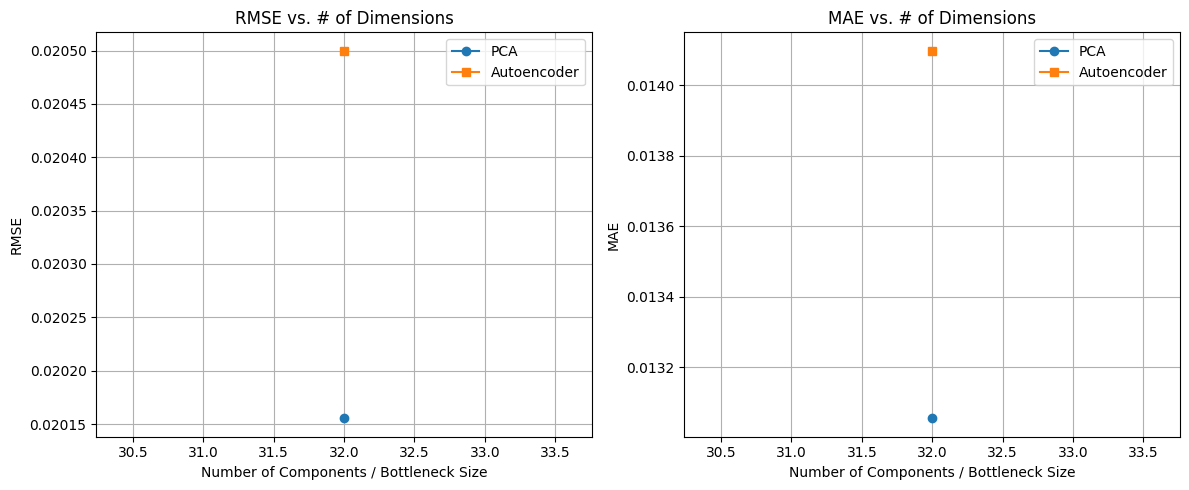

In [62]:
# Lists to store RMSE and MAE
rmse_pca, rmse_ae = [], []
mae_pca, mae_ae = [], []

# Iterate over different bottleneck sizes
for n in tqdm(bottleneck_sizes, desc="Computing errors"):
    # PCA reconstruction
    reconstructed_pca = (transformed[:, :n] @ pca.components_[:n]) + pca.mean_
    error_pca = data - reconstructed_pca
    rmse_pca.append(np.sqrt(np.mean(error_pca ** 2)))
    mae_pca.append(np.mean(np.abs(error_pca)))

    # Autoencoder reconstruction
    reconstructed_ae = pd.read_csv(
        f"../ukcensus/bottleneck_size_scan/census_geodemo__bottleneck_{n}_v0_3__reconstructed_outputs.csv", 
        index_col="ID"
    )
    error_ae = data - reconstructed_ae
    rmse_ae.append(np.sqrt(np.mean(error_ae ** 2)))
    mae_ae.append(np.mean(np.abs(error_ae)))

# Plot RMSE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(bottleneck_sizes, rmse_pca, marker='o', label="PCA")
plt.plot(bottleneck_sizes, rmse_ae, marker='s', label="Autoencoder")
plt.xlabel("Number of Components / Bottleneck Size")
plt.ylabel("RMSE")
plt.title("RMSE vs. # of Dimensions")
plt.legend()
plt.grid()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(bottleneck_sizes, mae_pca, marker='o', label="PCA")
plt.plot(bottleneck_sizes, mae_ae, marker='s', label="Autoencoder")
plt.xlabel("Number of Components / Bottleneck Size")
plt.ylabel("MAE")
plt.title("MAE vs. # of Dimensions")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()